In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
df2 = pd.read_csv('/content/drive/MyDrive/ML Codes/Feature Engineering/Normalization/wine_data.csv', header=None, usecols=[0, 1, 2])
df2.columns = ['Class_label', 'Alcohol', 'Malic_acid']

In [4]:
df2.head(5)

,Class_label,Alcohol,Malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [5]:
df2.isna().sum()

,0
Class_label,0
Alcohol,0
Malic_acid,0


In [6]:
df2.describe()

,Class_label,Alcohol,Malic_acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


<Axes: xlabel='Alcohol', ylabel='Malic_acid'>

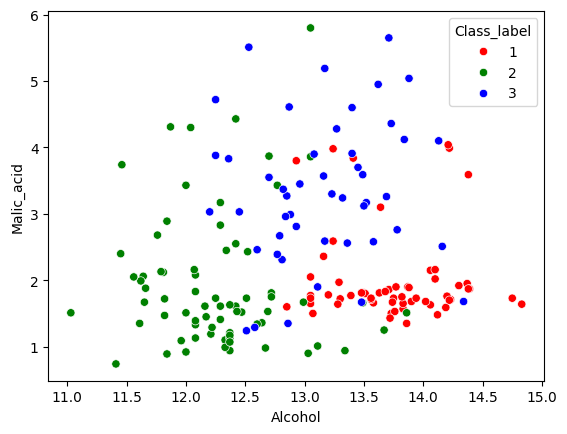

In [7]:
sns.scatterplot(data=df2,x='Alcohol',y='Malic_acid',hue='Class_label',palette={1: 'red', 2: 'green', 3: 'blue'})

## Train Test Split

In [8]:
from sklearn.model_selection import train_test_split


In [9]:
# featueres columns
X=df2.drop('Class_label',axis=1)
# Target columns
y=df2['Class_label']
# split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.3,random_state=0)

In [11]:
X_train.shape

(124, 2)

## **MinMax**

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler= MinMaxScaler()
# Fit
scaler.fit(X_train)
# Transform
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scaled

array([[0.72043011, 0.20378151],
       [0.31989247, 0.08403361],
       [0.60215054, 0.71218487],
       [0.57258065, 0.56302521],
       [0.76075269, 0.1302521 ],
       [0.48924731, 0.5       ],
       [0.75537634, 0.67857143],
       [0.61021505, 0.17436975],
       [0.54301075, 0.62394958],
       [0.39784946, 0.07352941],
       [0.33870968, 0.1092437 ],
       [0.46774194, 0.53361345],
       [0.5188172 , 0.53781513],
       [0.70967742, 0.07563025],
       [0.57258065, 0.30882353],
       [0.36021505, 0.0105042 ],
       [0.38709677, 0.13235294],
       [0.20967742, 0.25840336],
       [0.59408602, 0.64915966],
       [0.82526882, 0.26680672],
       [0.15591398, 0.09663866],
       [0.52688172, 0.16386555],
       [0.46774194, 0.31512605],
       [0.65860215, 0.16386555],
       [0.1155914 , 0.5987395 ],
       [0.27956989, 0.26680672],
       [0.21236559, 0.12184874],
       [0.65053763, 0.59033613],
       [0.31451613, 0.44957983],
       [0.54301075, 0.17647059],
       [0.

## Dataframe Conversion

In [15]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [16]:
X_train_scaled.sample(5)

,Alcohol,Malic_acid
49,0.897849,0.222689
30,0.575269,0.903361
40,0.327957,0.804622
51,0.454301,0.180672
120,0.360215,0.058824


In [17]:
X_test_scaled

,Alcohol,Malic_acid
0,0.728495,0.163866
1,0.473118,0.373950
2,0.360215,0.050420
3,0.680108,0.176471
4,0.543011,1.031513
5,0.142473,0.243697
6,0.814516,0.264706
7,0.357527,0.617647
8,0.327957,0.176471
9,0.282258,0.197479


In [ ]:
# Demo Model C

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [22]:
# Assuming you already loaded df2 correctly
X = df2[['Alcohol', 'Malic_acid']]
y = df2['Class_label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [23]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)


In [24]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)  # Tree models don’t need scaling
y_pred_dt = dt.predict(X_test)


In [25]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [26]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Logistic Regression Accuracy: 0.7407407407407407
              precision    recall  f1-score   support

           1       0.74      0.78      0.76        18
           2       0.76      0.76      0.76        21
           3       0.71      0.67      0.69        15

    accuracy                           0.74        54
   macro avg       0.74      0.74      0.74        54
weighted avg       0.74      0.74      0.74        54

Decision Tree Accuracy: 0.6851851851851852
              precision    recall  f1-score   support

           1       0.70      0.78      0.74        18
           2       0.76      0.62      0.68        21
           3       0.59      0.67      0.62        15

    accuracy                           0.69        54
   macro avg       0.68      0.69      0.68        54
weighted avg       0.69      0.69      0.69        54

Random Forest Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           1       0.74      0.78      0.76     

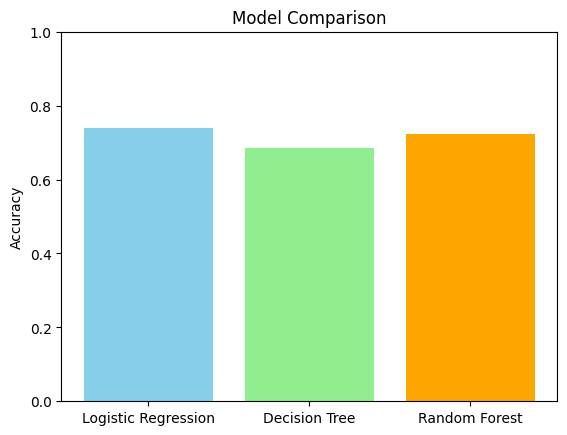

In [27]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'orange'])
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.show()
